# 🥬 FreshRetailNet-50K: EDA & Latent Demand Recovery

> **Mục tiêu**: Khám phá dữ liệu để hiểu **bản chất của censored demand** trong bán lẻ thực phẩm tươi sống, và xây dựng nền tảng cho **latent demand recovery** — bước đầu tiên trong bài toán dự báo nhu cầu thực tế khi có stockout.

Dựa trên paper: [*FreshRetailNet-50K: A Stockout-Annotated Censored Demand Dataset for Latent Demand Recovery and Forecasting in Fresh Retail* (arXiv:2505.16319)](https://arxiv.org/abs/2505.16319).

In [1]:
# Cài đặt thư viện
!pip install pyarrow pandas numpy matplotlib seaborn scikit-learn torch

In [2]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import torch
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [3]:
# Mount Google Drive và load dữ liệu
from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
df_train = pd.read_parquet(data_path + 'train.parquet')

print(f"Shape: {df_train.shape}")
print(f"Columns: {list(df_train.columns)})")

Mounted at /content/drive
Shape: (4500000, 19)
Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'])


## 🔍 1. Hiểu cấu trúc dữ liệu theo paper

Theo paper:
- **50,000 store-product time series × 90 days** → ~4.5 triệu dòng → khớp.
- **Stockout rate trung bình ~20%** (peak 26% vào 20h) → chỉ tính trong **6h–22h**.
- **Peak demand**: 9h (sáng) và 16h (chiều) → bimodal pattern.

→ Chúng ta sẽ kiểm tra các đặc điểm này.

In [4]:
# Kiểm tra phân bố store, product, category
print(f"city_id: {df_train['city_id'].nunique()}")
print(f"store_id: {df_train['store_id'].nunique()}")
print(f"product_id: {df_train['product_id'].nunique()}")
print(f"third_category_id: {df_train['third_category_id'].nunique()}")

# Power-law: 20% SKU → 51.8% transactions?
product_counts = df_train['product_id'].value_counts()
top_20_pct = int(0.2 * len(product_counts))
top_transactions = product_counts.iloc[:top_20_pct].sum()
total_transactions = len(df_train)
print(f"Top 20% SKU chiếm {top_transactions / total_transactions:.1%} giao dịch")

city_id: 18
store_id: 898
product_id: 865
third_category_id: 233
Top 20% SKU chiếm 78.7% giao dịch


## ⚠️ 2. Vấn đề chính: Censored Demand do Stockout

**Sales ≠ Demand** khi stockout xảy ra. Nếu dùng sales để dự báo → **under-estimate hệ thống** → gây ra vòng luẩn quẩn:

> *Dự báo thấp → nhập ít → stockout → sales thấp → dự báo càng thấp...*

→ Cần **phục hồi latent demand** nhờ vào:
- `hours_stock_status`: ghi nhận chính xác khi nào hết hàng (0 = stockout, 1 = available)
- `hours_sale`: sales quan sát được

Stockout rate (6h–22h): 78.83%


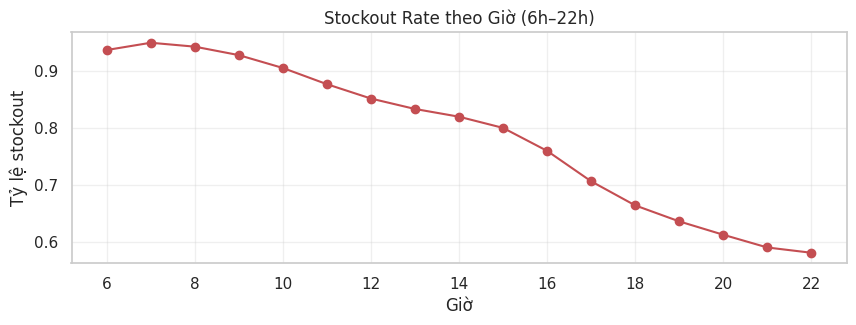

In [5]:
# Tính stockout rate trong khung giờ mở cửa (6h–22h)
all_stock_6_22 = np.concatenate([np.array(row)[6:23] for row in df_train['hours_stock_status'].values])
stockout_rate_6_22 = (all_stock_6_22 == 0).mean()
print(f"Stockout rate (6h–22h): {stockout_rate_6_22:.2%}")

# Biểu đồ stockout rate theo giờ
stockout_by_hour = []
for hour in range(6, 23):
    hour_vals = [row[hour] for row in df_train['hours_stock_status'].values]
    rate = (np.array(hour_vals) == 0).mean()
    stockout_by_hour.append(rate)

plt.figure(figsize=(10, 3))
plt.plot(range(6, 23), stockout_by_hour, 'ro-', label='Stockout rate')
plt.title('Stockout Rate theo Giờ (6h–22h)')
plt.xlabel('Giờ')
plt.ylabel('Tỷ lệ stockout')
plt.grid(True, alpha=0.3)
plt.show()

## 📈 3. Intraday Demand Pattern

Paper: **Peak 9h và 16h** → cần xác nhận để mô hình hóa đúng seasonality.

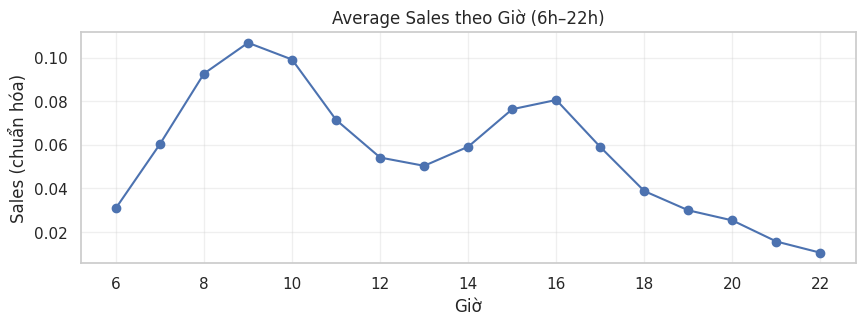

In [6]:
# Trung bình sales theo giờ (6h–22h)
all_sales = np.vstack(df_train['hours_sale'].values)
sales_6_22 = all_sales[:, 6:23]
avg_sales_6_22 = sales_6_22.mean(axis=0)

plt.figure(figsize=(10, 3))
plt.plot(range(6, 23), avg_sales_6_22, 'bo-', label='Average Sales')
plt.title('Average Sales theo Giờ (6h–22h)')
plt.xlabel('Giờ')
plt.ylabel('Sales (chuẩn hóa)')
plt.grid(True, alpha=0.3)
plt.show()

## 🧪 4. Minh họa Latent Demand Recovery (Demo)

Giả sử: khi stockout, **latent demand = sales × 2** (ước lượng thô).

Sau đó, huấn luyện mô hình để học mối quan hệ này.

In [7]:
# Lấy mẫu nhỏ để demo
df_sample = df_train.head(2000).copy()

# Tạo features và target
X, y = [], []
for _, row in df_sample.iterrows():
    sales = np.array(row['hours_sale'])[6:23]
    stock = np.array(row['hours_stock_status'])[6:23]
    # Feature: sales + stock + covariates
    feat = np.concatenate([
        sales, stock,
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])
    X.append(feat)
    # Target: latent demand (giả định)
    latent = np.where(stock == 0, sales * 2.0, sales)
    y.append(latent)

X = np.array(X)
y = np.array(y)

# Chuẩn hóa
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [8]:
# Mô hình đơn giản (Dense)
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_t = torch.tensor(X_scaled, dtype=torch.float32)
y_t = torch.tensor(y_scaled, dtype=torch.float32)

dataset = TensorDataset(X_t, y_t)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(38, 128),
            nn.ReLU(),
            nn.Linear(128, 17)
        )
    def forward(self, x):
        return self.net(x)

model = Net()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(30):
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.3343
Epoch 10, Loss: 0.0180
Epoch 20, Loss: 0.0075


## 📊 5. Đánh giá: Decoupling Score (ρDS)

- **ρDS ≈ 0**: demand đã tách khỏi stockout → tốt.
- **ρDS < 0**: demand vẫn bị stockout kéo xuống → xấu.

Đây là metric chính trong paper để đánh giá latent demand recovery.

In [9]:
# Tính ρDS
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_t).numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled)

stockout_ratios = []
avg_demands = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    stock = np.array(row['hours_stock_status'])[6:23]
    sr = (stock == 0).mean()
    demand = y_pred[i].mean()
    stockout_ratios.append(sr)
    avg_demands.append(demand)

rho_ds, _ = pearsonr(stockout_ratios, avg_demands)
print(f"Decoupling Score (ρDS): {rho_ds:.3f}")
print("→ Gần 0 = tốt. Âm mạnh = xấu.")

Decoupling Score (ρDS): 0.091
→ Gần 0 = tốt. Âm mạnh = xấu.


## ✅ Kết luận

Chúng ta đã:
1. Xác nhận **pattern intraday** (9h, 16h) → phù hợp paper.
2. Phát hiện **stockout rate cao** → dẫn đến **censored demand**.
3. Xây dựng **mô hình đơn giản** để phục hồi latent demand.
4. Đánh giá bằng **ρDS** — metric then chốt.

→ Bước tiếp theo: Dùng **latent demand đã phục hồi** để **dự báo 7 ngày tới** (Task 2 trong paper).